In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [23]:
df = pd.read_csv("../../data/New/df_messy.csv")
df.info()

C:\Users\ahyo\AppData\Local\Temp\ipykernel_51492\2750436862.py:1: DtypeWarning: Columns (2,45,78,79,80,81) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../data/New/df_messy.csv")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 399157 entries, 0 to 399156
Data columns (total 82 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Flooring                      256352 non-null  object 
 1   ViewYN                        359640 non-null  object 
 2   WaterfrontYN                  175 non-null     object 
 3   BasementYN                    9747 non-null    object 
 4   PoolPrivateYN                 358610 non-null  object 
 5   OriginalListPrice             398378 non-null  float64
 6   ListingKey                    399157 non-null  int64  
 7   ListAgentEmail                398296 non-null  object 
 8   CloseDate                     399157 non-null  object 
 9   ClosePrice                    399155 non-null  float64
 10  ListAgentFirstName            395752 non-null  object 
 11  ListAgentLastName             399120 non-null  object 
 12  Latitude                      398964 non-nul

## Week 3: Data Preprocessing

In [24]:
import re
import datetime
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [78]:
df['YearBuilt'].sort_values().head(30)

72598     1776.0
308731    1776.0
251560    1800.0
51441     1801.0
168651    1801.0
362024    1801.0
95967     1801.0
219517    1801.0
374965    1801.0
342465    1801.0
95734     1801.0
33396     1850.0
352516    1854.0
163674    1859.0
271569    1860.0
104547    1860.0
252541    1862.0
81960     1865.0
246287    1867.0
213546    1868.0
192540    1870.0
269871    1870.0
261612    1870.0
193321    1870.0
118439    1870.0
292982    1870.0
347491    1872.0
217862    1872.0
35144     1872.0
335099    1872.0
Name: YearBuilt, dtype: float64

In [26]:
df.groupby('StateOrProvince').size()

StateOrProvince
AL         2
AZ         8
BC         1
CA    399130
CO         2
FL         1
GA         1
ME         1
MO         1
NV         3
NY         1
OS         3
TN         1
TX         1
dtype: int64

There are so few listings in states other than California that it makes sense remove those rows entirely

In [88]:
# first copy df
df_cleaned = df.copy()

###################################################
# 1: Identify Impossible Values and Drop Duplicates
###################################################

# drop duplicates
df_cleaned = df_cleaned.drop_duplicates()

# drop rows with impossible or na values for the target variable ClosePrice
df_cleaned = df_cleaned[df_cleaned['ClosePrice'] > 1000]
df_cleaned = df_cleaned.dropna(subset=['ClosePrice'])

# convert impossible coordinates to NaN
invalid_coords = (
    (df_cleaned['Latitude'] < -90) | (df_cleaned['Latitude'] > 90) |
    (df_cleaned['Longitude'] < -180) | (df_cleaned['Longitude'] > 180) |
    (df_cleaned['Latitude'] == 0) | (df_cleaned['Longitude'] == 0)
)
df_cleaned.loc[invalid_coords,['Latitude','Longitude']] = np.nan

# LivingArea
df_cleaned.loc[df_cleaned['LivingArea'] <= 0, 'LivingArea'] = np.nan
# df_cleaned.loc[df_cleaned['LivingArea'] > 20000, 'LivingArea'] = np.nan

# ParkingTotal
df_cleaned.loc[df_cleaned['ParkingTotal'] < 0, 'ParkingTotal'] = np.nan
# df_cleaned.loc[df_cleaned['ParkingTotal'] > 20, 'ParkingTotal'] = np.nan

# LotSizeSquareFeet
df_cleaned.loc[df_cleaned['LotSizeSquareFeet'] <= 0, 'LotSizeSquareFeet'] = np.nan
# df_cleaned.loc[df_cleaned['LotSizeSquareFeet'] > 500000, 'LotSizeSquareFeet'] = np.nan

# YearBuilt
df_cleaned.loc[df_cleaned['YearBuilt'] < 1850, 'YearBuilt'] = np.nan

#################################################################
# 2: Drop Columns with > 60% NaN Values and single-valued columns
#################################################################

# keep columns with at least 60% non-null values
df_cleaned = df_cleaned.dropna(thresh=len(df_cleaned) * 0.60, axis=1)

# drop states other than CA
df_cleaned = df_cleaned[df_cleaned['StateOrProvince'] == 'CA']

# Drop columns with a single value
single_val_cols = df_cleaned.columns[df_cleaned.nunique() == 1]
df_cleaned = df_cleaned.drop(columns=single_val_cols)

###############################################
# 3: Change DateTime columns to DateTime format
###############################################

date_cols = df_cleaned.filter(regex='(?i)Date').columns.tolist()
for col in date_cols:
    df_cleaned[col] = pd.to_datetime(df_cleaned[col], errors='coerce')

################################
# 4: Drop Other Columns Manually
################################

# Redundant columns
redundant_cols = [
    'ListingKeyNumeric',
    'ListingId',
    'ListAgentFullName',
    'LotSizeAcres',
    'LotSizeArea'
]

# Columns with no predictive power
unhelpful_cols = [
    'ListAgentEmail',
    'ListAgentFirstName',
    'ListAgentLastName',
    'ListOfficeName',
    'BuyerOfficeName',
    'BuyerAgentMlsId',
    'BuyerAgentFirstName',
    'BuyerAgentLastName',
    'UnparsedAddress',
    'StreetNumberNumeric'
]

# Columns that leak information
leaky_cols = [
    'ListPrice',
    'OriginalListPrice',
    'PurchaseContractDate',
    'DaysOnMarket'
]

df_cleaned = df_cleaned.drop(columns=redundant_cols + leaky_cols + unhelpful_cols)

##################################
# 5: Convert YN Columns to Boolean
##################################

bool_cols = ['ViewYN', 'PoolPrivateYN', 'AttachedGarageYN', 'FireplaceYN', 'NewConstructionYN']

df_cleaned[bool_cols] = df_cleaned[bool_cols].astype('boolean')

##########################
# 6: Impute Missing Values
##########################

unknown_fill = ['Flooring', 'MLSAreaMajor', 'BuyerOfficeAOR', 'City', 'Levels', 'HighSchoolDistrict',
                'PostalCode', 'BuyerAgentAOR', 'ListAgentAOR']

zero_fill = ['AssociationFee', 'GarageSpaces', 'ParkingTotal']

median_fill = ['LivingArea', 'LotSizeSquareFeet', 'YearBuilt']

mode_fill = ['BedroomsTotal', 'BathroomsTotalInteger', 'Stories']

for col in unknown_fill:
    df_cleaned[col] = df_cleaned[col].fillna('Unknown')

for col in zero_fill:
    df_cleaned[col] = df_cleaned[col].fillna(0)

for col in median_fill:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

for col in mode_fill:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

# Drop missing latitude and Longitude rows
df_cleaned = df_cleaned.dropna(subset=['Latitude', 'Longitude'])

For now, I will keep nans in boolean valued columns because there is no easy interpretation of what a `nan` value means here

### Date distribution plots

#### CloseDate Distribution

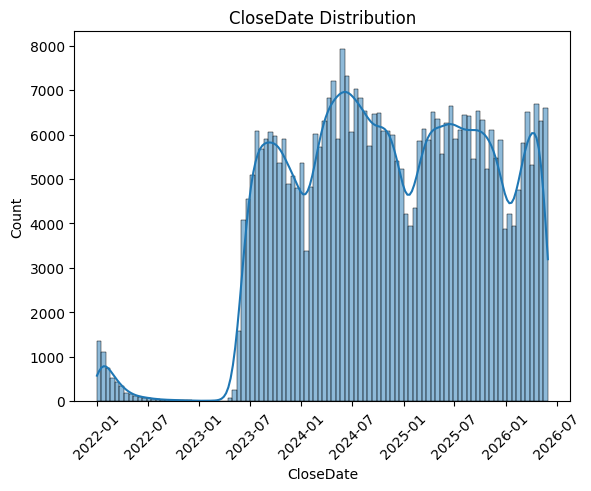

In [53]:
plt.figure()
sns.histplot(data=df_cleaned, x='CloseDate', bins = 100, kde=True)
plt.xticks(rotation=45)
plt.title('CloseDate Distribution')
plt.show()

#### Does `ClosePrice` have any relation with `CloseDate`?

In [85]:
Q1 = df_cleaned['ClosePrice'].quantile(0.25)
Q3 = df_cleaned['ClosePrice'].quantile(0.75)
IQR = Q3 - Q1

df_cleaned_no_outliers = df_cleaned[~((df_cleaned['ClosePrice'] < (Q1 - 1.5 * IQR)) | (df_cleaned['ClosePrice'] > (Q3 + 1.5 * IQR)))]

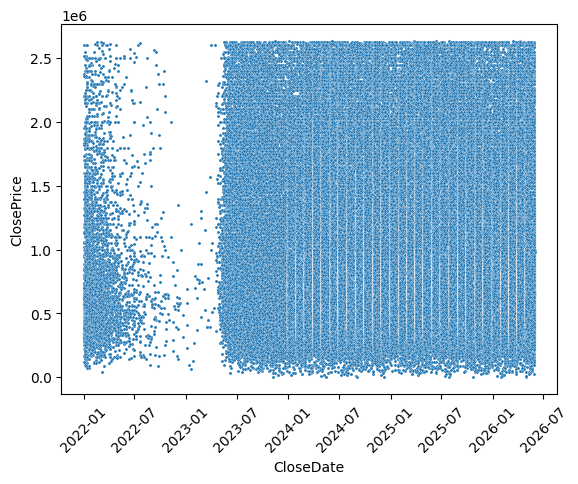

In [86]:
plt.figure()
sns.scatterplot(data=df_cleaned_no_outliers, x='CloseDate', y='ClosePrice', s=5)
plt.xticks(rotation=45)
plt.show()

### Creating training and testing sets

Export clean dataset so, I don't have to reclean everytime

In [97]:
df_cleaned.to_csv('../../data/New/df_cleaned.csv', index=False)

Function to split into training and testing by `CloseDate`

In [55]:
from dateutil.relativedelta import relativedelta

def train_test_split_by_month(df, date_col='CloseDate', n_train_months=6):
    df = df.copy()
    df[date_col] = pd.to_datetime(df[date_col])

    # most recent month present in the data
    max_date = df[date_col].max()
    test_month_start = max_date.replace(day=1)
    test_month_end = test_month_start + relativedelta(months=1)

    # training window: the n_train_months immediately before the test month
    train_start = test_month_start - relativedelta(months=n_train_months)
    train_end = test_month_start

    test_df = df[(df[date_col] >= test_month_start) & (df[date_col] < test_month_end)]
    train_df = df[(df[date_col] >= train_start) & (df[date_col] < train_end)]

    print(f"Test month: {test_month_start.date()} to {test_month_end.date()} ({len(test_df)} rows)")
    print(f"Train window: {train_start.date()} to {train_end.date()} ({len(train_df)} rows)")

    return train_df, test_df

# example usage
train_df, test_df = train_test_split_by_month(df_cleaned, date_col='CloseDate', n_train_months=6)

Test month: 2026-05-01 to 2026-06-01 (12022 rows)
Train window: 2025-11-01 to 2026-05-01 (59434 rows)


In [96]:
n = len(df_cleaned)

# 1) Missingness ranked — verifies my counts above
print("-----Ranked Missingness-----")
miss = (df_cleaned.isna().sum().to_frame("n_missing")
          .assign(pct=lambda d: (d.n_missing / n * 100).round(2), dtype=df_cleaned.dtypes.astype(str))
          .sort_values("n_missing", ascending=False))
print(miss[miss.n_missing > 0])

# 2) Cardinality of object cols → spot multi-value / free-text / PII
print("\n-----Number of Unique Entries-----")
print(df_cleaned.select_dtypes("object").nunique().sort_values(ascending=False))
print("\n-----Cardinality of Object Columns-----")
for c in ["Flooring","Levels","MLSAreaMajor","HighSchoolDistrict","ListAgentAOR"]:
    print(f"\n--- {c} ---\n{df_cleaned[c].value_counts(dropna=False).head(5)}")

# 3) Zeros / negatives / impossible values
print("\n-----Impossible Values-----")
num = df_cleaned.select_dtypes("number").columns
print(df_cleaned[num].describe().T[["min","25%","50%","75%","max"]])
print("\nzeros:\n", (df_cleaned[num] == 0).sum().sort_values(ascending=False))
print("\nnegatives:\n", (df_cleaned[num] < 0).sum().sort_values(ascending=False))

# 5) Sanity checks on the modeling fields
print("\nClosePrice <= 1000 :", (df_cleaned.ClosePrice <= 1000).sum())
print("LivingArea <= 0    :", (df_cleaned.LivingArea <= 0).sum())
print("YearBuilt < 1800   :", (df_cleaned.YearBuilt < 1800).sum())
print("Lat/Lon == 0       :", ((df_cleaned.Latitude == 0) | (df_cleaned.Longitude == 0)).sum())

# 6) PostalCode format
print("\n-----Postal Code Formats-----")
print(df_cleaned.PostalCode.astype(str).str.len().value_counts())

# 7) Duplicates
print("\n-----Duplicates-----")
print("dupe rows:", df_cleaned.duplicated().sum(), "| dupe keys:", df_cleaned.ListingKey.duplicated().sum())

-----Ranked Missingness-----
                          n_missing    pct           dtype
AttachedGarageYN              46070  11.55         boolean
PoolPrivateYN                 40464  10.14         boolean
NewConstructionYN             39499   9.90         boolean
ViewYN                        39397   9.88         boolean
ContractStatusChangeDate       8199   2.06  datetime64[ns]
FireplaceYN                    1939   0.49         boolean

-----Number of Unique Entries-----
PostalCode            3658
City                  1151
MLSAreaMajor          1094
HighSchoolDistrict     447
Flooring               341
BuyerOfficeAOR          75
CountyOrParish          64
BuyerAgentAOR           63
ListAgentAOR            62
Levels                  19
dtype: int64

-----Cardinality of Object Columns-----

--- Flooring ---
Flooring
Unknown        142710
Carpet,Tile     28446
Wood            25648
Tile,Wood       22116
Laminate        19092
Name: count, dtype: int64

--- Levels ---
Levels
One         

In [93]:
(df_cleaned["AssociationFee"] == 0).mean()

np.float64(0.750349748532059)

### Notes:
1. `LotSizeArea` has no units (`LotSizeUnits` does not exist), so I will prefer `LotSizeSquareFeet` assuming those two are the same
2. 